# Cursive L Analyzer - Pixel-Based Version (No Calibration)

In [3]:
"""
Simple Cursive L Drawing Interface
Just draw and save NPZ file with custom filename
"""

import tkinter as tk
from tkinter import ttk, messagebox
import numpy as np
import time
from datetime import datetime

class SimpleCursiveLDrawer:
    def __init__(self, root):
        self.root = root
        self.root.title("Cursive 'l' Drawing Tool")
        self.root.geometry("800x600")
        
        # Data storage
        self.points = []
        self.timestamps = []
        self.is_drawing = False
        self.strokes = []
        self.current_stroke = []
        self.current_timestamps = []
        
        # Canvas dimensions
        self.canvas_width = 750
        self.canvas_height = 450
        
        # Writing area boundaries
        self.writing_area = {
            'left': 50,
            'right': 700,
            'top': 50,
            'bottom': 400
        }
        
        # Create UI
        self.setup_ui()
        
    def setup_ui(self):
        """Setup the main UI"""
        # Configure root grid
        self.root.grid_columnconfigure(0, weight=1)
        self.root.grid_rowconfigure(0, weight=1)
        
        main_frame = ttk.Frame(self.root, padding="10")
        main_frame.grid(row=0, column=0, sticky=(tk.W, tk.E, tk.N, tk.S))
        main_frame.grid_columnconfigure(0, weight=1)
        
        # Instructions
        instructions = ttk.Label(main_frame, 
                                text="Draw continuous cursive 'l's within the bounded area. Click and drag to draw.",
                                font=('Arial', 12))
        instructions.grid(row=0, column=0, pady=(0, 10), sticky=tk.W+tk.E)
        
        # Create frame for canvas
        canvas_frame = ttk.Frame(main_frame)
        canvas_frame.grid(row=1, column=0, pady=(0, 15), sticky=tk.W+tk.E)
        canvas_frame.grid_columnconfigure(0, weight=1)
        
        # Drawing canvas
        self.canvas = tk.Canvas(canvas_frame, width=self.canvas_width, height=self.canvas_height, 
                               bg='white', relief=tk.SUNKEN, borderwidth=2)
        self.canvas.grid(row=0, column=0)
        
        # Setup canvas with boundaries
        self.setup_canvas()
        
        # Bind mouse events
        self.canvas.bind("<Button-1>", self.start_drawing)
        self.canvas.bind("<B1-Motion>", self.draw)
        self.canvas.bind("<ButtonRelease-1>", self.stop_drawing)
        
        # Filename input frame
        filename_frame = ttk.Frame(main_frame)
        filename_frame.grid(row=2, column=0, pady=(0, 15), sticky=tk.W+tk.E)
        filename_frame.grid_columnconfigure(1, weight=1)
        
        ttk.Label(filename_frame, text="Filename:").grid(row=0, column=0, padx=(0, 5), sticky=tk.W)
        self.filename_var = tk.StringVar(value="my_cursive_l_data")
        self.filename_entry = ttk.Entry(filename_frame, textvariable=self.filename_var, width=30)
        self.filename_entry.grid(row=0, column=1, padx=(0, 5), sticky=tk.W+tk.E)
        ttk.Label(filename_frame, text=".npz").grid(row=0, column=2, sticky=tk.W)
        
        # Control buttons frame
        button_frame = ttk.Frame(main_frame)
        button_frame.grid(row=3, column=0, pady=(0, 15), sticky=tk.W+tk.E)
        button_frame.grid_columnconfigure(0, weight=1)
        
        # Create a sub-frame to center the buttons
        button_container = ttk.Frame(button_frame)
        button_container.grid(row=0, column=0)
        
        self.export_btn = ttk.Button(button_container, text="Save NPZ File", 
                                     command=self.export_npz_data, width=15)
        self.export_btn.grid(row=0, column=0, padx=(0, 10))
        
        self.clear_btn = ttk.Button(button_container, text="Clear Canvas", 
                                   command=self.clear_canvas, width=15)
        self.clear_btn.grid(row=0, column=1)
        
        # Status label
        self.status_label = ttk.Label(main_frame, text="Ready to draw", 
                                     font=('Arial', 10))
        self.status_label.grid(row=4, column=0, pady=(0, 5), sticky=tk.W+tk.E)
        
        # Line IDs for visualization
        self.line_ids = []
    
    def setup_canvas(self):
        """Setup canvas with boundaries and guide lines"""
        # Draw writing area boundary
        self.canvas.create_rectangle(
            self.writing_area['left'], 
            self.canvas_height - self.writing_area['bottom'],
            self.writing_area['right'], 
            self.canvas_height - self.writing_area['top'],
            outline='red', width=2, dash=(5, 3)
        )
        
        # Add "WRITE HERE" text
        center_x = (self.writing_area['left'] + self.writing_area['right']) / 2
        self.canvas.create_text(center_x, 25, text="WRITING AREA", 
                               font=('Arial', 12, 'bold'), fill='red')
        
        # Add guide lines
        baseline_y = 100
        canvas_baseline_y = self.canvas_height - baseline_y
        self.canvas.create_line(self.writing_area['left'], canvas_baseline_y, 
                               self.writing_area['right'], canvas_baseline_y, 
                               fill='lightblue', width=1, dash=(5, 5))
        self.canvas.create_text(self.writing_area['left'] - 20, canvas_baseline_y, 
                               text="baseline", font=('Arial', 7), fill='blue', anchor='e')
        
        ascender_y = 200
        canvas_ascender_y = self.canvas_height - ascender_y
        self.canvas.create_line(self.writing_area['left'], canvas_ascender_y, 
                               self.writing_area['right'], canvas_ascender_y, 
                               fill='lightgreen', width=1, dash=(5, 5))
        self.canvas.create_text(self.writing_area['left'] - 20, canvas_ascender_y, 
                               text="ascender", font=('Arial', 7), fill='green', anchor='e')
        
        # Add axis labels (pixels only)
        for x in range(0, 751, 100):
            self.canvas.create_text(x, self.canvas_height - 5, text=str(x), 
                                   font=('Arial', 8), fill='black')
        
        for y in range(0, 451, 50):
            self.canvas.create_text(25, self.canvas_height - y, text=str(y), 
                                   font=('Arial', 8), fill='black')
    
    def canvas_to_cartesian(self, x, y):
        """Convert canvas coordinates to Cartesian"""
        return x, self.canvas_height - y
    
    def cartesian_to_canvas(self, x, y):
        """Convert Cartesian coordinates to canvas"""
        return x, self.canvas_height - y
    
    def is_within_writing_area(self, x, y):
        """Check if point is within the writing boundary"""
        x_cart, y_cart = self.canvas_to_cartesian(x, y)
        return (self.writing_area['left'] <= x_cart <= self.writing_area['right'] and 
                self.writing_area['top'] <= y_cart <= self.writing_area['bottom'])
    
    def start_drawing(self, event):
        """Start recording drawing data"""
        if not self.is_within_writing_area(event.x, event.y):
            self.status_label.config(text="Please draw within the bounded area!", foreground='red')
            return
        
        self.is_drawing = True
        self.status_label.config(text="Drawing...", foreground='black')
        x_cart, y_cart = self.canvas_to_cartesian(event.x, event.y)
        self.current_stroke = [(x_cart, y_cart)]
        self.current_timestamps = [time.time()]
    
    def draw(self, event):
        """Record drawing points and visualize"""
        if self.is_drawing:
            if not self.is_within_writing_area(event.x, event.y):
                self.status_label.config(text="Stay within the bounded area!", foreground='orange')
                return
            
            x_cart, y_cart = self.canvas_to_cartesian(event.x, event.y)
            
            if len(self.current_stroke) > 0:
                x1_cart, y1_cart = self.current_stroke[-1]
                x1_canvas, y1_canvas = self.cartesian_to_canvas(x1_cart, y1_cart)
                x2_canvas, y2_canvas = event.x, event.y
                
                line_id = self.canvas.create_line(x1_canvas, y1_canvas, x2_canvas, y2_canvas, 
                                                 width=2, fill='blue', 
                                                 capstyle=tk.ROUND, smooth=tk.TRUE)
                self.line_ids.append(line_id)
            
            self.current_stroke.append((x_cart, y_cart))
            self.current_timestamps.append(time.time())
    
    def stop_drawing(self, event):
        """Stop recording and save stroke"""
        if self.is_drawing:
            self.is_drawing = False
            if len(self.current_stroke) > 1:
                self.strokes.append({
                    'points': self.current_stroke.copy(),
                    'timestamps': self.current_timestamps.copy(),
                    'duration': self.current_timestamps[-1] - self.current_timestamps[0]
                })
                self.points.extend(self.current_stroke)
                self.timestamps.extend(self.current_timestamps)
            self.current_stroke = []
            self.current_timestamps = []
            self.status_label.config(text="Ready to draw", foreground='black')
    
    def clear_canvas(self):
        """Clear the canvas and reset data"""
        self.canvas.delete("all")
        self.setup_canvas()
        self.points = []
        self.timestamps = []
        self.strokes = []
        self.line_ids = []
        self.status_label.config(text="Canvas cleared - Ready to draw")
    
    def export_npz_data(self):
        """Export raw data to numpy file with custom filename"""
        if not self.points:
            messagebox.showwarning("No Data", "Please draw some cursive 'l's before saving")
            return
        
        # Get filename from entry
        filename = self.filename_var.get().strip()
        if not filename:
            messagebox.showwarning("Invalid Filename", "Please enter a filename")
            return
        
        # Add .npz extension if not present
        if not filename.endswith('.npz'):
            filename += '.npz'
        
        try:
            points_array = np.array(self.points)
            timestamps_array = np.array(self.timestamps)
            
            # Prepare stroke data for saving
            stroke_data = []
            for stroke in self.strokes:
                stroke_data.append({
                    'points': stroke['points'],
                    'duration': stroke['duration']
                })
            
            # Save NPZ file with stroke information
            np.savez(filename, 
                    x_pixels=points_array[:, 0],
                    y_pixels=points_array[:, 1],
                    timestamps=timestamps_array - timestamps_array[0],
                    stroke_data=np.array(stroke_data, dtype=object),
                    total_strokes=len(self.strokes))
            
            messagebox.showinfo("Save Complete", f"Data saved as {filename}")
            self.status_label.config(text=f"Data saved as {filename}")
            
        except Exception as e:
            messagebox.showerror("Save Error", f"Error saving file: {str(e)}")
            self.status_label.config(text="Error saving file")


def OpenWritingPanel():
    """Main entry point for simple drawer"""
    root = tk.Tk()
    
    # Set theme if available
    try:
        style = ttk.Style()
        if "vista" in style.theme_names():
            style.theme_use("vista")
        elif "clam" in style.theme_names():
            style.theme_use("clam")
    except:
        pass
    
    app = SimpleCursiveLDrawer(root)
    root.mainloop()



# Calibrated Cursive L Analyzer

In [21]:
"""
Fixed Two-Function Handwriting Analyzer
Function 1: get_calibration() - returns conversion factor using proper EDID logic
Function 2: analyze_handwriting(filepath, conversion_factor) - outputs plots and results
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
import json
from datetime import datetime
import os
import sys
import tkinter as tk
import math
import ctypes

# Windows-specific imports for EDID
if sys.platform.startswith("win"):
    from winreg import OpenKey, QueryValueEx, EnumKey, HKEY_LOCAL_MACHINE
    try:
        ctypes.windll.shcore.SetProcessDpiAwareness(2)
    except Exception:
        try:
            ctypes.windll.user32.SetProcessDPIAware()
        except Exception:
            pass

# ============= FUNCTION 1: CALIBRATION (FIXED) =============
def get_calibration():
    """
    Get screen calibration conversion factor using proper EDID detection
    
    Returns:
        tuple: (ppcm_x, ppcm_y) - pixels per cm in X and Y directions
    """
    if sys.platform.startswith("win"):
        return _get_windows_calibration()
    else:
        return _get_fallback_calibration()


def _get_windows_calibration():
    """Windows-specific EDID-based calibration (from working original)"""
    try:
        monitors = _list_monitors_with_edid()
        if monitors and len(monitors) > 0:
            # Use primary monitor (first in list)
            primary = monitors[0]
            print(f"Calibration detected: {primary['method']} - {primary['ppcm_x']:.2f} x {primary['ppcm_y']:.2f} pixels/cm")
            return primary['ppcm_x'], primary['ppcm_y']
        else:
            return _get_dpi_calibration()
    except Exception as e:
        print(f"Windows calibration failed: {e}")
        return _get_fallback_calibration()


def _list_monitors_with_edid():
    """List all monitors with EDID info (from original working code)"""
    monitors = []
    
    try:
        user32 = ctypes.windll.user32
        
        # Win32 structures
        class RECT(ctypes.Structure):
            _fields_ = [("left", ctypes.c_long), ("top", ctypes.c_long),
                       ("right", ctypes.c_long), ("bottom", ctypes.c_long)]
        
        class MONITORINFOEXW(ctypes.Structure):
            _fields_ = [("cbSize", ctypes.c_ulong),
                       ("rcMonitor", RECT),
                       ("rcWork", RECT),
                       ("dwFlags", ctypes.c_ulong),
                       ("szDevice", ctypes.c_wchar * 32)]
        
        class DISPLAY_DEVICEW(ctypes.Structure):
            _fields_ = [("cb", ctypes.c_uint),
                       ("DeviceName", ctypes.c_wchar * 32),
                       ("DeviceString", ctypes.c_wchar * 128),
                       ("StateFlags", ctypes.c_uint),
                       ("DeviceID", ctypes.c_wchar * 128),
                       ("DeviceKey", ctypes.c_wchar * 128)]
        
        # Function definitions
        EnumDisplayMonitors = user32.EnumDisplayMonitors
        EnumDisplayMonitors.argtypes = [ctypes.c_void_p, ctypes.c_void_p, ctypes.c_void_p, ctypes.c_long]
        EnumDisplayMonitors.restype = ctypes.c_int
        
        GetMonitorInfoW = user32.GetMonitorInfoW
        GetMonitorInfoW.argtypes = [ctypes.c_void_p, ctypes.POINTER(MONITORINFOEXW)]
        GetMonitorInfoW.restype = ctypes.c_int
        
        EnumDisplayDevicesW = user32.EnumDisplayDevicesW
        EnumDisplayDevicesW.argtypes = [ctypes.c_wchar_p, ctypes.c_uint, ctypes.POINTER(DISPLAY_DEVICEW), ctypes.c_uint]
        EnumDisplayDevicesW.restype = ctypes.c_int
        
        # Per-monitor DPI
        try:
            shcore = ctypes.windll.shcore
            GetDpiForMonitor = shcore.GetDpiForMonitor
            MDT_EFFECTIVE_DPI = 0
        except:
            GetDpiForMonitor = None
        
        DISPLAY_DEVICE_ACTIVE = 0x00000001
        
        # Collect HMONITORs
        hmons = []
        @ctypes.WINFUNCTYPE(ctypes.c_int, ctypes.c_void_p, ctypes.c_void_p, ctypes.POINTER(RECT), ctypes.c_double)
        def enum_proc(hmon, hdc, lprc, lparam):
            r = lprc.contents
            hmons.append((hmon, (r.right - r.left, r.bottom - r.top)))
            return 1
        
        EnumDisplayMonitors(0, 0, enum_proc, 0)
        
        # Helper function to get device ID
        def device_id_for_display_name(szDevice):
            i = 0
            dd = DISPLAY_DEVICEW()
            dd.cb = ctypes.sizeof(DISPLAY_DEVICEW)
            while EnumDisplayDevicesW(None, i, ctypes.byref(dd), 0):
                adapter_name = dd.DeviceName
                j = 0
                ddmon = DISPLAY_DEVICEW()
                ddmon.cb = ctypes.sizeof(DISPLAY_DEVICEW)
                while EnumDisplayDevicesW(adapter_name, j, ctypes.byref(ddmon), 0):
                    if ddmon.StateFlags & DISPLAY_DEVICE_ACTIVE:
                        if ddmon.DeviceName and ddmon.DeviceName.startswith(szDevice):
                            return ddmon.DeviceID
                    j += 1
                    ddmon = DISPLAY_DEVICEW()
                    ddmon.cb = ctypes.sizeof(DISPLAY_DEVICEW)
                i += 1
                dd = DISPLAY_DEVICEW()
                dd.cb = ctypes.sizeof(DISPLAY_DEVICEW)
            return ""
        
        # Process each monitor
        for hmon, (w_px, h_px) in hmons:
            mi = MONITORINFOEXW()
            mi.cbSize = ctypes.sizeof(MONITORINFOEXW)
            GetMonitorInfoW(ctypes.c_void_p(hmon), ctypes.byref(mi))
            szDevice = mi.szDevice
            
            dev_id = device_id_for_display_name(szDevice)
            vendor = ""
            if dev_id and "\\" in dev_id:
                parts = dev_id.split("\\")
                if len(parts) >= 2:
                    vendor = parts[1]
            
            edid_w_cm = edid_h_cm = None
            method = ""
            ppcm_x = ppcm_y = None
            
            if vendor:
                ew, eh = _read_edid_cm_for_vendor(vendor)
                if ew and eh:
                    edid_w_cm, edid_h_cm = ew, eh
                    ppcm_x = w_px / float(ew)
                    ppcm_y = h_px / float(eh)
                    method = "EDID"
            
            if ppcm_x is None:
                # Try per-monitor DPI
                if GetDpiForMonitor:
                    xdpi = ctypes.c_uint()
                    ydpi = ctypes.c_uint()
                    hr = GetDpiForMonitor(ctypes.c_void_p(hmon), MDT_EFFECTIVE_DPI,
                                        ctypes.byref(xdpi), ctypes.byref(ydpi))
                    if hr == 0:
                        ppi = (xdpi.value + ydpi.value) / 2.0
                        ppcm = ppi / 2.54
                        ppcm_x = ppcm_y = ppcm
                        method = "per_monitor_dpi"
                
                if ppcm_x is None:
                    # Fallback to default DPI
                    root = tk.Tk()
                    root.withdraw()
                    try:
                        dpi = float(root.winfo_fpixels('1i'))
                    except:
                        dpi = 96.0
                    finally:
                        root.destroy()
                    ppcm = dpi / 2.54
                    ppcm_x = ppcm_y = ppcm
                    method = "tk_dpi_fallback"
            
            monitors.append({
                'ppcm_x': ppcm_x,
                'ppcm_y': ppcm_y,
                'method': method
            })
            break  # Use first monitor only
            
    except Exception as e:
        print(f"Error listing monitors: {e}")
    
    return monitors


def _read_edid_cm_for_vendor(vendor_code):
    """Read EDID dimensions for a specific vendor (from original working code)"""
    try:
        DISPLAY_REG_KEY = r"SYSTEM\CurrentControlSet\Enum\DISPLAY"
        
        with OpenKey(HKEY_LOCAL_MACHINE, DISPLAY_REG_KEY) as root:
            i = 0
            while True:
                try:
                    vend = EnumKey(root, i)
                    i += 1
                except OSError:
                    break
                
                if vend != vendor_code:
                    continue
                
                # Found vendor; enumerate instances
                with OpenKey(root, vend) as vend_key:
                    j = 0
                    while True:
                        try:
                            inst = EnumKey(vend_key, j)
                            j += 1
                        except OSError:
                            break
                        
                        try:
                            with OpenKey(vend_key, inst + r"\Device Parameters") as dp:
                                edid, _ = QueryValueEx(dp, "EDID")
                                if isinstance(edid, (bytes, bytearray)) and len(edid) >= 0x17:
                                    # Read physical dimensions from EDID bytes 0x15 and 0x16
                                    w_cm = int(edid[0x15])
                                    h_cm = int(edid[0x16])
                                    if w_cm > 0 and h_cm > 0:
                                        return w_cm, h_cm
                        except OSError:
                            pass
    except OSError:
        pass
    return None, None


def _get_dpi_calibration():
    """DPI-based calibration"""
    try:
        root = tk.Tk()
        root.withdraw()
        dpi = root.winfo_fpixels('1i')
        root.destroy()
        ppcm = dpi / 2.54
        print(f"Calibration detected: DPI - {ppcm:.2f} x {ppcm:.2f} pixels/cm")
        return ppcm, ppcm
    except Exception:
        return _get_fallback_calibration()


def _get_fallback_calibration():
    """Fallback calibration (96 DPI)"""
    ppcm = 96.0 / 2.54
    print(f"Calibration detected: Fallback - {ppcm:.2f} x {ppcm:.2f} pixels/cm")
    return ppcm, ppcm


# ============= FUNCTION 2: ANALYSIS =============


def _get_stroke_type(total_strokes):
    """Get stroke type description"""
    if total_strokes == 1:
        return "Single continuous stroke"
    elif total_strokes <= 3:
        return "Few strokes (minimal lifting)"
    elif total_strokes <= 6:
        return "Multiple strokes (moderate lifting)"
    else:
        return "Many strokes (frequent lifting)"


def _segment_letters(x_coords, y_coords, timestamps):
    """Segment trajectory into individual letters"""
    if len(y_coords) < 10:
        return []
    
    # Smooth coordinates
    window_length = min(11, len(y_coords) if len(y_coords) % 2 == 1 else len(y_coords) - 1)
    y_smooth = savgol_filter(y_coords, window_length, 3)
    x_smooth = savgol_filter(x_coords, window_length, 3)
    
    # Detect peaks (letter tops)
    min_height = np.std(y_smooth) * 0.5
    baseline = np.percentile(y_smooth, 25)
    peaks, _ = find_peaks(y_smooth, height=baseline + min_height, distance=20)
    
    if len(peaks) == 0:
        return []
    
    segments = []
    for i, peak in enumerate(peaks):
        # Get boundaries
        if i == 0:
            start_idx = 0
        else:
            prev_peak = peaks[i-1]
            valley_region = y_smooth[prev_peak:peak]
            if len(valley_region) > 0:
                valley_idx = np.argmin(valley_region) + prev_peak
                start_idx = valley_idx
            else:
                start_idx = prev_peak
        
        if i == len(peaks) - 1:
            end_idx = len(x_coords) - 1
        else:
            next_peak = peaks[i+1]
            valley_region = y_smooth[peak:next_peak]
            if len(valley_region) > 0:
                valley_idx = np.argmin(valley_region) + peak
                end_idx = valley_idx
            else:
                end_idx = next_peak
        
        # Extract segment
        seg_x = x_smooth[start_idx:end_idx+1]
        seg_y = y_smooth[start_idx:end_idx+1]
        seg_t = timestamps[start_idx:end_idx+1]
        
        segments.append({
            'letter_number': i + 1,
            'x_coords': seg_x,
            'y_coords': seg_y,
            'timestamps': seg_t
        })
    
    return segments


def _calculate_letter_metrics(segment):
    """Calculate metrics for a single letter"""
    x_coords = segment['x_coords']
    y_coords = segment['y_coords']
    timestamps = segment['timestamps']
    
    if len(x_coords) < 2:
        return None
    
    # Amplitude
    amplitude_cm = float(np.max(y_coords) - np.min(y_coords))
    
    # Time
    time_taken = float(timestamps[-1] - timestamps[0]) if len(timestamps) > 1 else 0.0
    
    # Distance
    distances = np.sqrt(np.diff(x_coords)**2 + np.diff(y_coords)**2)
    total_distance_cm = float(np.sum(distances))
    
    # Speed
    avg_speed = float(total_distance_cm / time_taken) if time_taken > 0 else 0.0
    
    # Jerk
    jerk_count, jerk_positions = _calculate_jerk(x_coords, y_coords, timestamps)
    
    return {
        'letter_number': segment['letter_number'],
        'amplitude_cm': amplitude_cm,
        'time_taken_seconds': time_taken,
        'total_distance_cm': total_distance_cm,
        'avg_speed_cm_per_sec': avg_speed,
        'jerk_count': jerk_count,
        'jerk_positions': jerk_positions
    }


def _calculate_jerk(x_coords, y_coords, timestamps):
    """Calculate jerk using 5-point windows"""
    if len(x_coords) < 10:
        return 0, []
    
    jerk_values = []
    jerk_indices = []
    window_size = 5
    
    # Process 5-point windows
    for i in range(0, len(x_coords) - window_size + 1, window_size // 2):
        window_x = x_coords[i:i + window_size]
        window_y = y_coords[i:i + window_size]
        window_t = timestamps[i:i + window_size]
        
        if len(window_x) < 5:
            continue
        
        dt = window_t[-1] - window_t[0]
        if dt <= 0:
            continue
        
        # Velocity using endpoints
        vx = (window_x[-1] - window_x[0]) / dt
        vy = (window_y[-1] - window_y[0]) / dt
        v_magnitude = np.sqrt(vx**2 + vy**2)
        
        jerk_values.append(v_magnitude)
        jerk_indices.append(i + window_size // 2)
    
    if len(jerk_values) < 2:
        return 0, []
    
    # Find jerk events
    velocity_changes = np.abs(np.diff(jerk_values))
    jerk_positions = []
    
    if len(velocity_changes) > 0:
        jerk_threshold = np.percentile(velocity_changes, 75)
        high_jerk_indices = np.where(velocity_changes > jerk_threshold)[0]
        
        for idx in high_jerk_indices:
            if idx + 1 < len(jerk_indices):
                pos_idx = jerk_indices[idx + 1]
                if pos_idx < len(x_coords):
                    jerk_positions.append({
                        'x_cm': float(x_coords[pos_idx]),
                        'y_cm': float(y_coords[pos_idx]),
                        'time_seconds': float(timestamps[pos_idx])
                    })
        
        return len(high_jerk_indices), jerk_positions
    
    return 0, []


def analyze_handwriting(filepath, conversion_factor):
    """
    Analyze handwriting data and create plots
    
    Args:
        filepath: Path to NPZ file from Part-1
        conversion_factor: Tuple (ppcm_x, ppcm_y) from get_calibration()
        
    Returns:
        dict: Analysis results
    """
    ppcm_x, ppcm_y = conversion_factor
    
    # Extract filename without extension for folder and file naming
    base_filename = os.path.splitext(os.path.basename(filepath))[0]
    
    # Create output folder with the filename
    output_folder = base_filename
    os.makedirs(output_folder, exist_ok=True)
    print(f"Created output folder: {output_folder}")
    
    # Load data
    print(f"Loading data from: {filepath}")
    data = np.load(filepath, allow_pickle=True)
    
    x_pixels = data['x_pixels']
    y_pixels = data['y_pixels']
    timestamps = data['timestamps']
    
    # Get stroke info if available
    total_strokes = int(data['total_strokes']) if 'total_strokes' in data else 1
    stroke_type = _get_stroke_type(total_strokes)
    
    print(f"Loaded {len(x_pixels)} points, {total_strokes} strokes")
    
    # Convert to cm
    x_cm = x_pixels / ppcm_x
    y_cm = y_pixels / ppcm_y
    
    # Segment letters
    letter_segments = _segment_letters(x_cm, y_cm, timestamps)
    print(f"Detected {len(letter_segments)} letters")
    
    # Calculate metrics for each letter
    letter_metrics = []
    for segment in letter_segments:
        metrics = _calculate_letter_metrics(segment)
        if metrics:
            letter_metrics.append(metrics)
    
    # Calculate overall statistics
    total_time = float(timestamps[-1] - timestamps[0])
    total_distance = sum(letter['total_distance_cm'] for letter in letter_metrics)
    overall_avg_speed = float(total_distance / total_time) if total_time > 0 else 0.0
    total_jerk_events = sum(letter['jerk_count'] for letter in letter_metrics)
    
    # Compile results
    results = {
        'summary': {
            'total_letters': len(letter_metrics),
            'total_strokes': total_strokes,
            'stroke_type': stroke_type,
            'total_time_seconds': total_time,
            'total_distance_cm': total_distance,
            'overall_avg_speed_cm_per_sec': overall_avg_speed,
            'total_jerk_events': total_jerk_events
        },
        'letters': letter_metrics,
        'calibration': {
            'ppcm_x': ppcm_x,
            'ppcm_y': ppcm_y
        }
    }
    
    # Create plots
    _create_plots(x_cm, y_cm, letter_metrics, results, output_folder, base_filename)
    
    # Copy original NPZ file to output folder
    import shutil
    npz_destination = os.path.join(output_folder, f"{base_filename}.npz")
    shutil.copy2(filepath, npz_destination)
    print(f"Original NPZ copied to: {npz_destination}")
    
    # Save JSON with custom filename
    json_filename = os.path.join(output_folder, f"{base_filename}_json.json")
    with open(json_filename, 'w') as f:
        json.dump(results, f, indent=2)
    print(f"Analysis results saved to: {json_filename}")
    
    # Print summary
    _print_summary(results)
    
    return results


def _create_plots(x_cm, y_cm, letter_metrics, results, output_folder, base_filename):
    """Create analysis plots"""
    fig = plt.figure(figsize=(15, 10))
    fig.suptitle('Handwriting Analysis Results', fontsize=16, fontweight='bold')
    
    # Plot 1: Trajectory with colored letters and jerk points
    ax1 = plt.subplot(2, 3, 1)
    
    # Normalize entire trajectory to start from origin
    norm_x_cm = x_cm - x_cm[0]
    norm_y_cm = y_cm - y_cm[0]
    
    # Define colors for different letters
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(letter_metrics), 1)))
    
    # Get letter segments from the normalized data
    letter_segments = _segment_letters(norm_x_cm, norm_y_cm, np.arange(len(norm_x_cm)))
    
    # Plot each letter in different color
    for i, (segment, color) in enumerate(zip(letter_segments, colors)):
        seg_x = segment['x_coords']
        seg_y = segment['y_coords']
        
        ax1.plot(seg_x, seg_y, color=color, linewidth=2, 
                label=f'Letter {i+1}', alpha=0.8)
        
        # Mark start point of each letter
        ax1.scatter(seg_x[0], seg_y[0], color=color, s=100, 
                   marker='o', edgecolor='black', linewidth=1)
        
        # Mark end point of each letter
        ax1.scatter(seg_x[-1], seg_y[-1], color=color, s=100, 
                   marker='s', edgecolor='black', linewidth=1)
    
    # Add overall start and end points
    ax1.scatter(norm_x_cm[0], norm_y_cm[0], color='green', s=150, 
               marker='D', edgecolor='black', linewidth=2, label='Writing Start', zorder=10)
    ax1.scatter(norm_x_cm[-1], norm_y_cm[-1], color='red', s=150, 
               marker='D', edgecolor='black', linewidth=2, label='Writing End', zorder=10)
    
    # Add jerk points (normalize relative to entire trajectory start)
    all_jerk_x = []
    all_jerk_y = []
    for letter in letter_metrics:
        for jerk_pos in letter['jerk_positions']:
            # Normalize jerk position relative to entire trajectory start
            norm_jerk_x = jerk_pos['x_cm'] - x_cm[0]
            norm_jerk_y = jerk_pos['y_cm'] - y_cm[0]
            all_jerk_x.append(norm_jerk_x)
            all_jerk_y.append(norm_jerk_y)
    
    if all_jerk_x:
        ax1.scatter(all_jerk_x, all_jerk_y, color='orange', s=80, 
                   marker='x', linewidth=3, alpha=0.9, label=f'Jerks ({len(all_jerk_x)})')
    
    ax1.set_title('Writing Trajectory (Normalized to Origin)')
    ax1.set_xlabel('X (cm) - Normalized')
    ax1.set_ylabel('Y (cm) - Normalized')
    
    # Create custom legend
    from matplotlib.lines import Line2D
    legend_elements = []
    for i, color in enumerate(colors[:len(letter_segments)]):
        legend_elements.append(Line2D([0], [0], color=color, lw=2, 
                                    label=f'Letter {i+1}'))
    legend_elements.append(Line2D([0], [0], marker='D', color='green', 
                                 lw=0, markersize=8, label='Writing Start'))
    legend_elements.append(Line2D([0], [0], marker='D', color='red', 
                                 lw=0, markersize=8, label='Writing End'))
    legend_elements.append(Line2D([0], [0], marker='o', color='gray', 
                                 lw=0, markersize=6, label='Letter Start'))
    legend_elements.append(Line2D([0], [0], marker='s', color='gray', 
                                 lw=0, markersize=6, label='Letter End'))
    if all_jerk_x:
        legend_elements.append(Line2D([0], [0], marker='x', color='orange', 
                                     lw=0, markersize=8, label='Jerk Events'))
    
    ax1.legend(handles=legend_elements, loc='upper right', fontsize=8)
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal')
    
    # Plot 2: Amplitudes
    ax2 = plt.subplot(2, 3, 2)
    if letter_metrics:
        letter_nums = [l['letter_number'] for l in letter_metrics]
        amplitudes = [l['amplitude_cm'] for l in letter_metrics]
        bars = ax2.bar(letter_nums, amplitudes, color=colors[:len(letter_metrics)], 
                      edgecolor='black', alpha=0.8)
        ax2.axhline(y=np.mean(amplitudes), color='red', linestyle='--', 
                   label=f'Mean: {np.mean(amplitudes):.2f} cm', linewidth=2)
        ax2.legend()
    ax2.set_title('Letter Amplitudes')
    ax2.set_xlabel('Letter Number')
    ax2.set_ylabel('Amplitude (cm)')
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Times
    ax3 = plt.subplot(2, 3, 3)
    if letter_metrics:
        times = [l['time_taken_seconds'] for l in letter_metrics]
        bars = ax3.bar(letter_nums, times, color=colors[:len(letter_metrics)], 
                      edgecolor='black', alpha=0.8)
        ax3.axhline(y=np.mean(times), color='red', linestyle='--',
                   label=f'Mean: {np.mean(times):.2f} s', linewidth=2)
        ax3.legend()
    ax3.set_title('Time per Letter')
    ax3.set_xlabel('Letter Number')
    ax3.set_ylabel('Time (seconds)')
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Speeds
    ax4 = plt.subplot(2, 3, 4)
    if letter_metrics:
        speeds = [l['avg_speed_cm_per_sec'] for l in letter_metrics]
        bars = ax4.bar(letter_nums, speeds, color=colors[:len(letter_metrics)], 
                      edgecolor='black', alpha=0.8)
        ax4.axhline(y=np.mean(speeds), color='red', linestyle='--',
                   label=f'Mean: {np.mean(speeds):.2f} cm/s', linewidth=2)
        ax4.legend()
    ax4.set_title('Speed per Letter')
    ax4.set_xlabel('Letter Number')
    ax4.set_ylabel('Speed (cm/s)')
    ax4.grid(True, alpha=0.3)
    
    # Plot 5: Jerks
    ax5 = plt.subplot(2, 3, 5)
    if letter_metrics:
        jerks = [l['jerk_count'] for l in letter_metrics]
        bars = ax5.bar(letter_nums, jerks, color=colors[:len(letter_metrics)], 
                      edgecolor='black', alpha=0.8)
        ax5.axhline(y=np.mean(jerks), color='red', linestyle='--',
                   label=f'Mean: {np.mean(jerks):.1f}', linewidth=2)
        ax5.legend()
    ax5.set_title('Jerk Events per Letter')
    ax5.set_xlabel('Letter Number')
    ax5.set_ylabel('Jerk Count')
    ax5.grid(True, alpha=0.3)
    
    # Plot 6: Summary
    ax6 = plt.subplot(2, 3, 6)
    ax6.axis('off')
    
    summary = results['summary']
    summary_text = f"""SUMMARY
    
Letters: {summary['total_letters']}
Strokes: {summary['total_strokes']}
Style: {summary['stroke_type']}

Time: {summary['total_time_seconds']:.2f} s
Distance: {summary['total_distance_cm']:.2f} cm
Speed: {summary['overall_avg_speed_cm_per_sec']:.2f} cm/s
Jerks: {summary['total_jerk_events']}

Calibration: {results['calibration']['ppcm_x']:.1f} x {results['calibration']['ppcm_y']:.1f} ppcm
    """
    
    ax6.text(0.1, 0.9, summary_text, transform=ax6.transAxes,
            fontsize=10, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle="round", facecolor="lightgray", alpha=0.5))
    
    plt.tight_layout()
    
    # Save plot with custom filename in output folder
    plot_filename = os.path.join(output_folder, f"{base_filename}_analysis_image.png")
    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
    print(f"Analysis plots saved to: {plot_filename}")
    
    plt.show()


def _print_summary(results):
    """Print analysis summary"""
    print("\n" + "="*60)
    print("HANDWRITING ANALYSIS SUMMARY")
    print("="*60)
    
    summary = results['summary']
    letters = results['letters']
    
    print(f"Letters detected: {summary['total_letters']}")
    print(f"Strokes used: {summary['total_strokes']}")
    print(f"Writing style: {summary['stroke_type']}")
    print(f"Total time: {summary['total_time_seconds']:.2f} seconds")
    print(f"Total distance: {summary['total_distance_cm']:.2f} cm")
    print(f"Overall speed: {summary['overall_avg_speed_cm_per_sec']:.2f} cm/s")
    print(f"Total jerk events: {summary['total_jerk_events']}")
    
    print(f"\nINDIVIDUAL LETTERS:")
    print(f"{'#':<4} {'Amp(cm)':<8} {'Time(s)':<8} {'Speed(cm/s)':<12} {'Jerks':<6}")
    print("-" * 45)
    
    for letter in letters:
        print(f"{letter['letter_number']:<4} "
              f"{letter['amplitude_cm']:<8.2f} "
              f"{letter['time_taken_seconds']:<8.2f} "
              f"{letter['avg_speed_cm_per_sec']:<12.2f} "
              f"{letter['jerk_count']:<6}")
    
    print("="*60)


# ============= USAGE FUNCTIONS =============
def quick_analysis(filepath):
    """
    Complete analysis with auto-calibration
    
    Args:
        filepath: Path to NPZ file
        
    Returns:
        Analysis results
    """
    conversion_factor = get_calibration()
    return analyze_handwriting(filepath, conversion_factor)


def custom_analysis(filepath, ppcm_x, ppcm_y):
    """
    Analysis with custom calibration
    
    Args:
        filepath: Path to NPZ file
        ppcm_x: Pixels per cm in X
        ppcm_y: Pixels per cm in Y
        
    Returns:
        Analysis results
    """
    print(f"Using custom calibration: {ppcm_x:.2f} x {ppcm_y:.2f} pixels/cm")
    conversion_factor = (ppcm_x, ppcm_y)
    return analyze_handwriting(filepath, conversion_factor)




# analysis

In [8]:
OpenWritingPanel()

Calibration detected: EDID - 56.47 x 56.84 pixels/cm
Created output folder: test3
Loading data from: test3.npz
Loaded 533 points, 1 strokes
Detected 6 letters
Analysis plots saved to: test3\test3_analysis_image.png


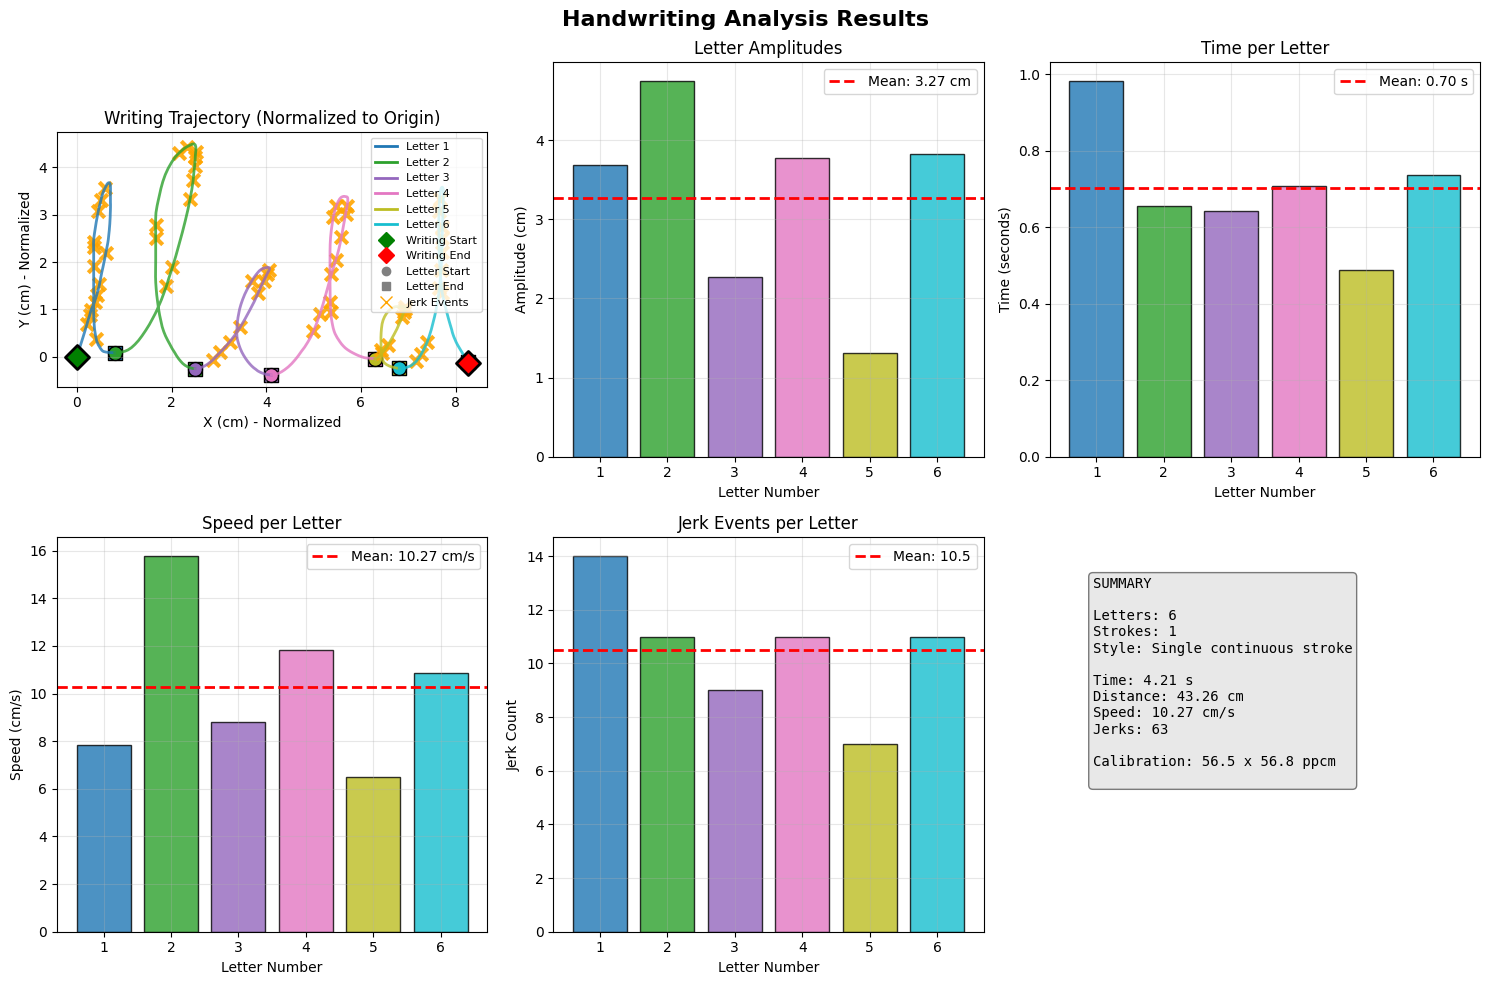

Original NPZ copied to: test3\test3.npz
Analysis results saved to: test3\test3_json.json

HANDWRITING ANALYSIS SUMMARY
Letters detected: 6
Strokes used: 1
Writing style: Single continuous stroke
Total time: 4.21 seconds
Total distance: 43.26 cm
Overall speed: 10.27 cm/s
Total jerk events: 63

INDIVIDUAL LETTERS:
#    Amp(cm)  Time(s)  Speed(cm/s)  Jerks 
---------------------------------------------
1    3.69     0.98     7.85         14    
2    4.75     0.66     15.77        11    
3    2.28     0.64     8.80         9     
4    3.78     0.71     11.83        11    
5    1.31     0.49     6.50         7     
6    3.83     0.74     10.87        11    


In [23]:

# Your file
input_path = 'test3.npz'

# Method 1: Two-step process
conversion_factor = get_calibration()
results = analyze_handwriting(input_path, conversion_factor)

# # Method 2: One-liner with auto-calibration
# results = quick_analysis(input_path)

# # Method 3: Custom calibration
# results = custom_analysis(input_path, 40.0, 40.0)